## Introduction

The objective of this task is to predict whether a loan applicant is likely to default on a loan.

We use a Loan Prediction dataset containing applicant details such as income, loan amount, education, and credit history.

This is a binary classification problem.


In [124]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline
plt.style.use('default')

In [125]:
# Make sure the file is in the same folder as your notebook
df = pd.read_csv('train.csv')   # ← Change name if different

print("Shape:", df.shape)
df.head()

Shape: (614, 13)


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [126]:
# Handling Missing Values
df['Gender'] = df['Gender'].fillna(df['Gender'].mode()[0])
df['Married'] = df['Married'].fillna(df['Married'].mode()[0])
df['Dependents'] = df['Dependents'].fillna(df['Dependents'].mode()[0])
df['Self_Employed'] = df['Self_Employed'].fillna(df['Self_Employed'].mode()[0])

df['LoanAmount'] = df['LoanAmount'].fillna(df['LoanAmount'].median())
df['Loan_Amount_Term'] = df['Loan_Amount_Term'].fillna(df['Loan_Amount_Term'].mode()[0])
df['Credit_History'] = df['Credit_History'].fillna(df['Credit_History'].mode()[0])

print("Missing Values Left:", df.isnull().sum().sum())

Missing Values Left: 0


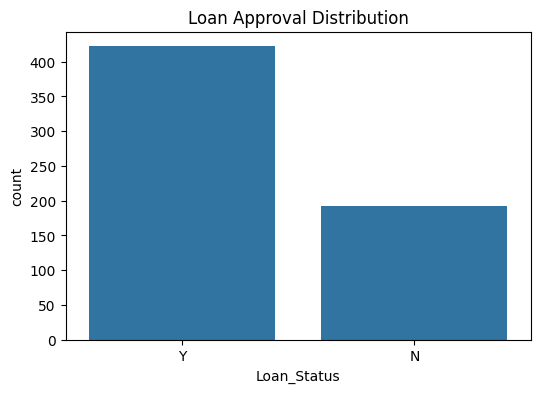

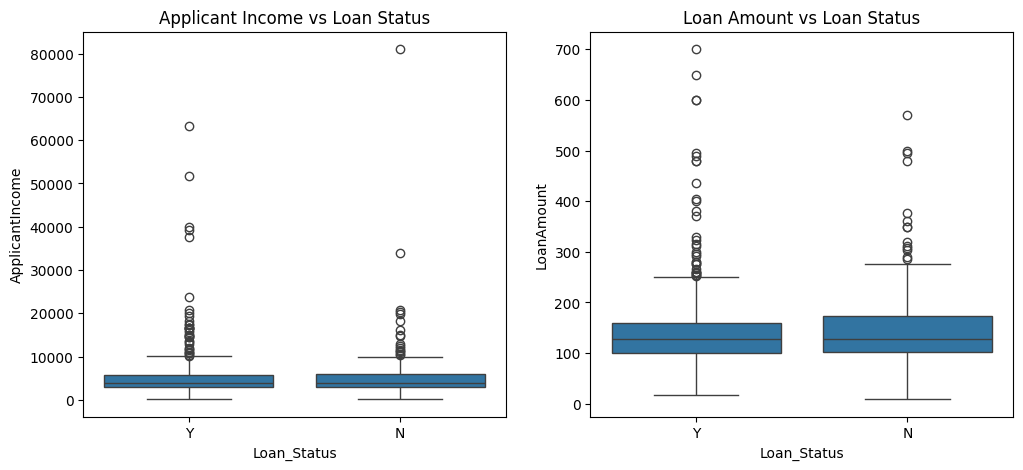

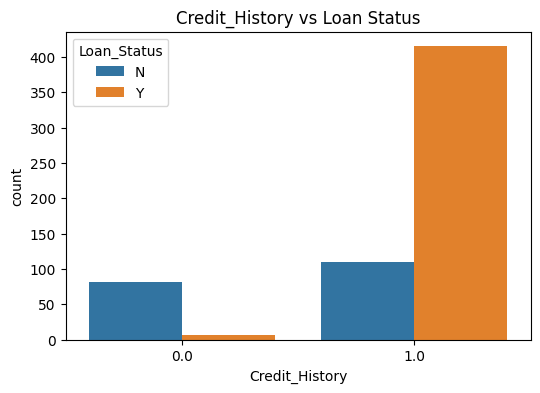

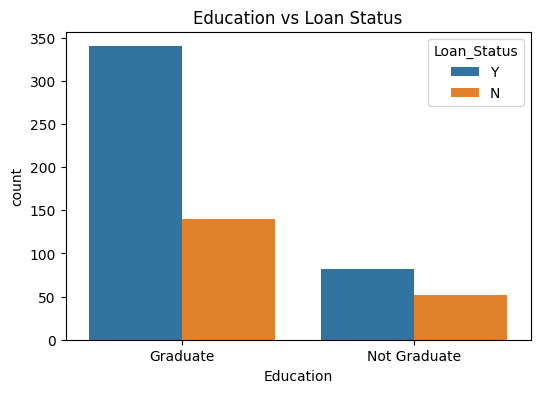

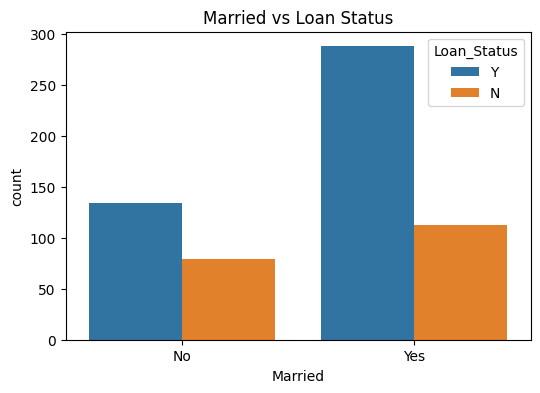

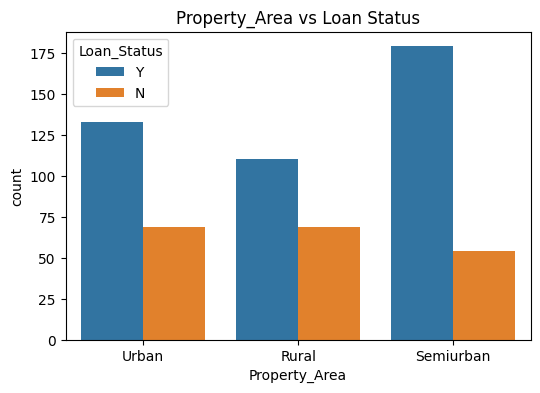

In [127]:
# 1. Target Distribution
plt.figure(figsize=(6,4))
sns.countplot(x='Loan_Status', data=df)
plt.title('Loan Approval Distribution')
plt.show()

# 2. Income & Loan Amount
fig, axes = plt.subplots(1, 2, figsize=(12,5))
sns.boxplot(x='Loan_Status', y='ApplicantIncome', data=df, ax=axes[0])
axes[0].set_title('Applicant Income vs Loan Status')
sns.boxplot(x='Loan_Status', y='LoanAmount', data=df, ax=axes[1])
axes[1].set_title('Loan Amount vs Loan Status')
plt.show()

# 3. Important Categorical Features
cat_features = ['Credit_History', 'Education', 'Married', 'Property_Area']
for col in cat_features:
    plt.figure(figsize=(6,4))
    sns.countplot(x=col, hue='Loan_Status', data=df)
    plt.title(f'{col} vs Loan Status')
    plt.show()

In [128]:
import pandas as pd
import numpy as np

# ====================== FULL RESET & CLEAN PROCESS ======================

# 1. Reload the original dataset (This is the key!)
df = pd.read_csv('train.csv')   # Change filename if yours is different

print("Original Shape:", df.shape)

# 2. Data Cleaning
df['Gender'] = df['Gender'].fillna(df['Gender'].mode()[0])
df['Married'] = df['Married'].fillna(df['Married'].mode()[0])
df['Dependents'] = df['Dependents'].fillna(df['Dependents'].mode()[0])
df['Self_Employed'] = df['Self_Employed'].fillna(df['Self_Employed'].mode()[0])
df['LoanAmount'] = df['LoanAmount'].fillna(df['LoanAmount'].median())
df['Loan_Amount_Term'] = df['Loan_Amount_Term'].fillna(df['Loan_Amount_Term'].mode()[0])
df['Credit_History'] = df['Credit_History'].fillna(df['Credit_History'].mode()[0])

# 3. Feature Engineering
df['Total_Income'] = df['ApplicantIncome'] + df['CoapplicantIncome']
df['LoanAmount_log'] = np.log(df['LoanAmount'] + 1)

# 4. Drop unnecessary columns
df = df.drop(['Loan_ID', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount'], axis=1)

# 5. Encoding
df = pd.get_dummies(df, drop_first=True)

# 6. Fix Target Column
if 'Loan_Status_Y' in df.columns:
    df = df.rename(columns={'Loan_Status_Y': 'Loan_Status'})
elif 'Loan_Status' in df.columns and df['Loan_Status'].dtype == 'object':
    df['Loan_Status'] = df['Loan_Status'].map({'Y': 1, 'N': 0})

# Final Check
print("\nFinal Shape:", df.shape)
print("Columns:", df.columns.tolist())
print("\nTarget Distribution:\n", df['Loan_Status'].value_counts())
print("\n✅ Success! Data is ready for modeling.")

Original Shape: (614, 13)

Final Shape: (614, 14)
Columns: ['Loan_Amount_Term', 'Credit_History', 'Total_Income', 'LoanAmount_log', 'Gender_Male', 'Married_Yes', 'Dependents_1', 'Dependents_2', 'Dependents_3+', 'Education_Not Graduate', 'Self_Employed_Yes', 'Property_Area_Semiurban', 'Property_Area_Urban', 'Loan_Status']

Target Distribution:
 Loan_Status
True     422
False    192
Name: count, dtype: int64

✅ Success! Data is ready for modeling.


In [129]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Prepare data
X = df.drop('Loan_Status', axis=1)
y = df['Loan_Status']

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

# Train model
model = LogisticRegression(max_iter=500)
model.fit(X_train, y_train)

# Predict & Evaluate
y_pred = model.predict(X_test)

print("Accuracy:", round(accuracy_score(y_test, y_pred), 4))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.7727

Confusion Matrix:
 [[21 33]
 [ 2 98]]

Classification Report:
               precision    recall  f1-score   support

       False       0.91      0.39      0.55        54
        True       0.75      0.98      0.85       100

    accuracy                           0.77       154
   macro avg       0.83      0.68      0.70       154
weighted avg       0.81      0.77      0.74       154



In [130]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(max_depth=5, random_state=42)
dt_model.fit(X_train, y_train)
dt_pred = dt_model.predict(X_test)

print("Decision Tree Accuracy:", round(accuracy_score(y_test, dt_pred), 4))

Decision Tree Accuracy: 0.7403


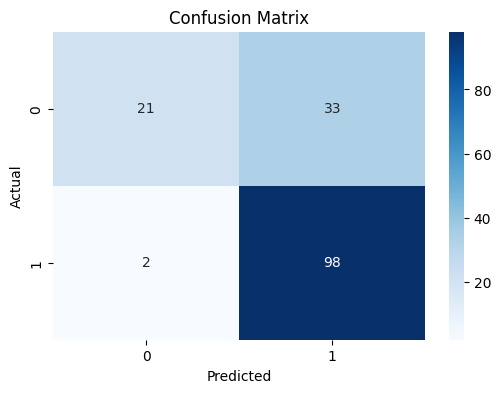


Detailed Report:
              precision    recall  f1-score   support

       False       0.91      0.39      0.55        54
        True       0.75      0.98      0.85       100

    accuracy                           0.77       154
   macro avg       0.83      0.68      0.70       154
weighted avg       0.81      0.77      0.74       154



In [131]:

# Confusion Matrix Heatmap (Nice Visualization)
plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

print("\nDetailed Report:")
print(classification_report(y_test, y_pred))

In [132]:
import joblib
joblib.dump(model, 'loan_prediction_model.pkl')
print("Model saved successfully!")

Model saved successfully!


## Conclusion

This project focused on predicting loan approval using classification techniques.

Key Insights:
- Credit history is one of the most important features
- Applicants with higher income have higher approval chances
- Logistic Regression performed well with good accuracy

This task helped in understanding data cleaning, visualization, and binary classification.
